In [2]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import zipfile
import librosa
import torch
import numpy as np
from SMT import *
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from tqdm import tqdm
import json

In [3]:
# Update directory and zip names
subjects = [251, 422, 652, 777, 1272]
AUDIO_DIRS = [Path(f"./data/LibriSpeech/dev-clean/{str(subj)}") for subj in subjects]


### Get audio files from single person

In [ ]:

for i, dir in enumerate(AUDIO_DIRS):
    patch_lengths = [20, 50, 100, 200, 300]
    results = grid_search_patch_size_smt(dir, patch_lengths)
    with open(f'results_{subjects[i]}.json', 'w') as f:
        json.dump(results, f, indent=2)  




smt_per_patch_length:   0%|          | 0/5 [00:00<?, ?it/s]

start smt on patch_size: 20
calc log mels
patch utterances
apply kmeans
spectral decomp


smt_per_patch_length:  20%|██        | 1/5 [01:54<07:37, 114.46s/it]

start smt on patch_size: 50
calc log mels
patch utterances
apply kmeans
spectral decomp


smt_per_patch_length:  40%|████      | 2/5 [04:08<06:18, 126.22s/it]

...

start smt on patch_size: 20
calc log mels
patch utterances
apply kmeans
spectral decomp


smt_per_patch_length:  20%|██        | 1/5 [01:58<07:53, 118.30s/it]

start smt on patch_size: 50
calc log mels
patch utterances
apply kmeans
spectral decomp


smt_per_patch_length:  20%|██        | 1/5 [03:12<12:50, 192.70s/it]


KeyboardInterrupt: 

In [5]:
# Update directory and zip names
subjects = [251, 422, 652, 777, 1272]
AUDIO_DIRS = [Path(f"./data/LibriSpeech/dev-clean/{str(subj)}") for subj in subjects]


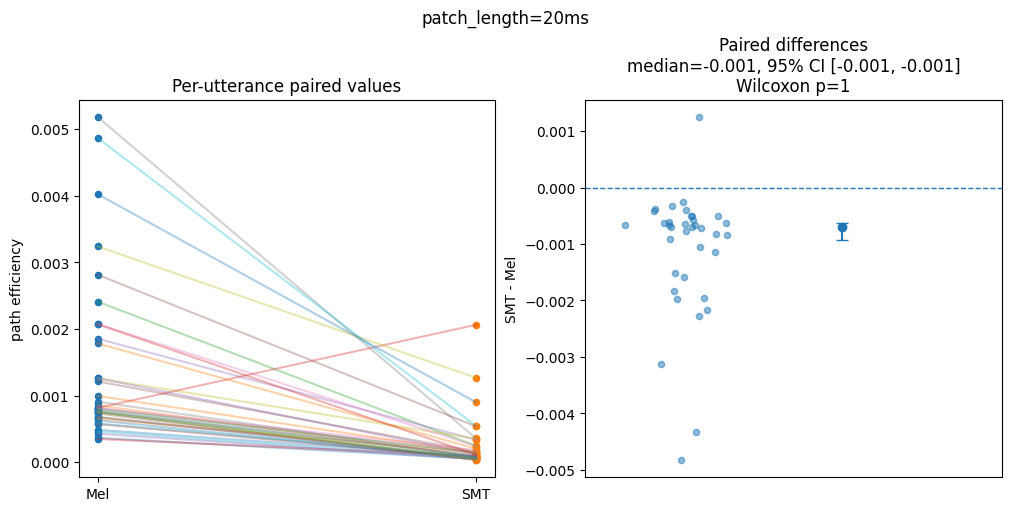

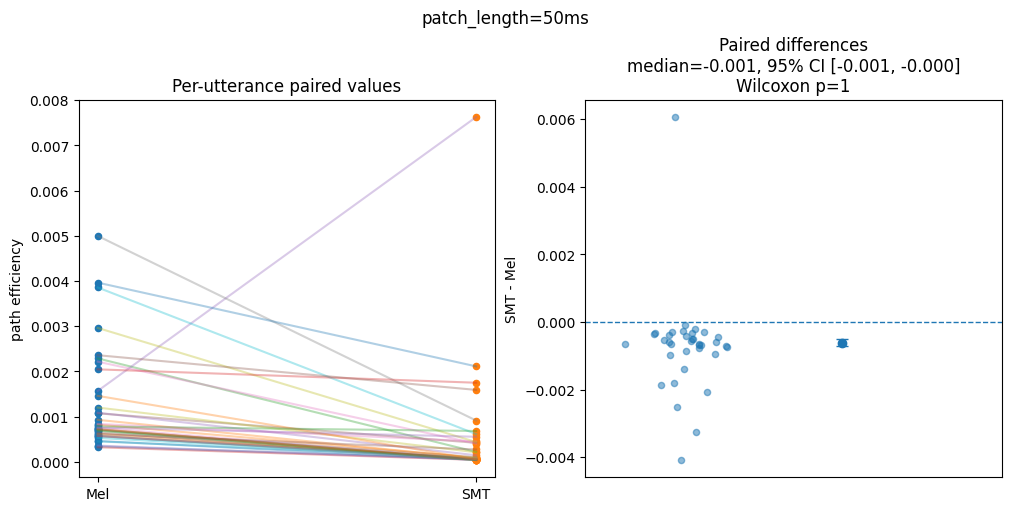

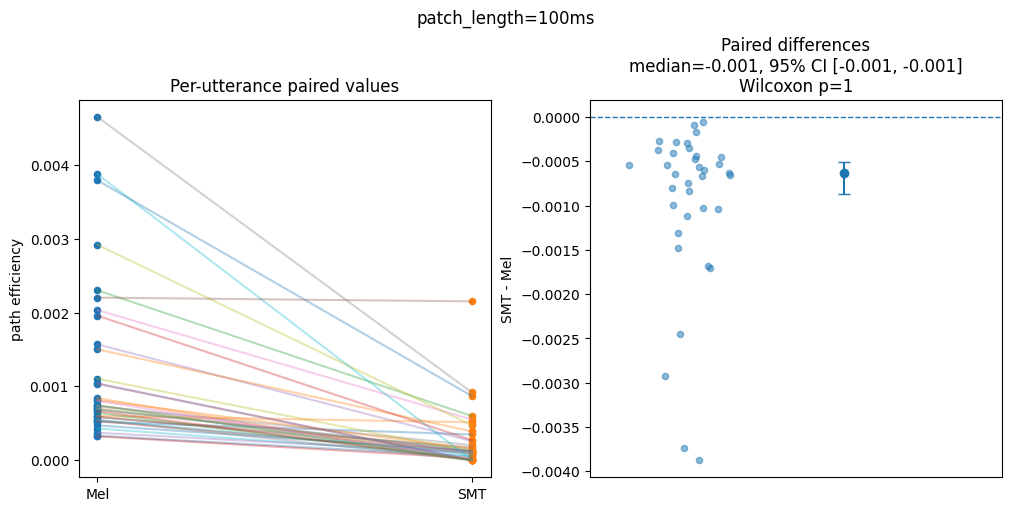

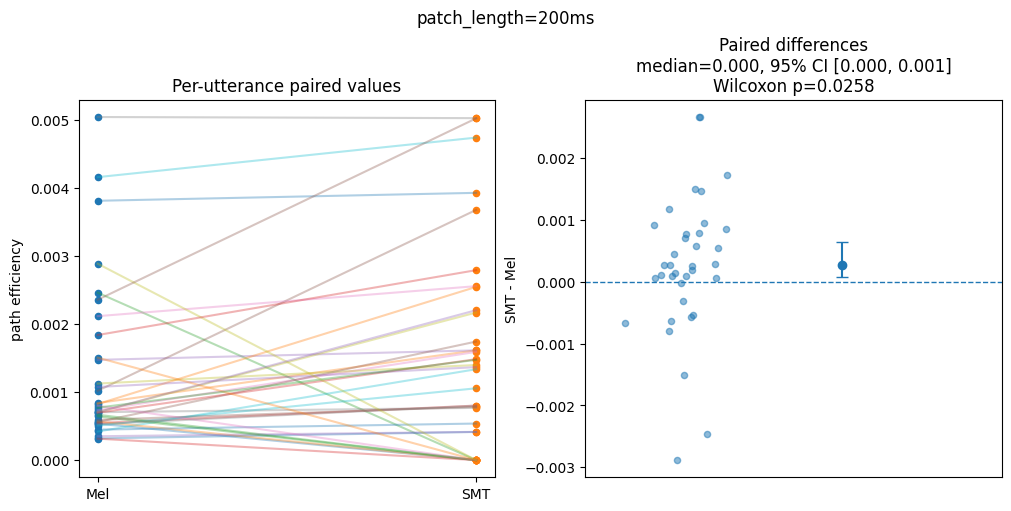

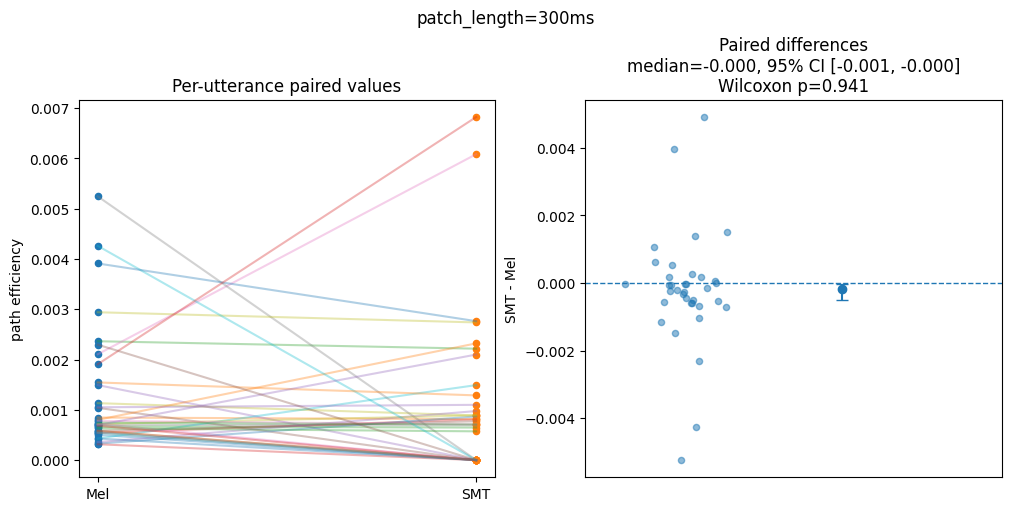

In [91]:
with open('results_422.json') as f:
    results = json.load(f)
for i in patch_lengths:
    plot_paired_comparison(results[str(i)]['mel_stats']['path_efficiency'], results[str(i)]['smt_stats']['path_efficiency'], i, "path efficiency", "greater")

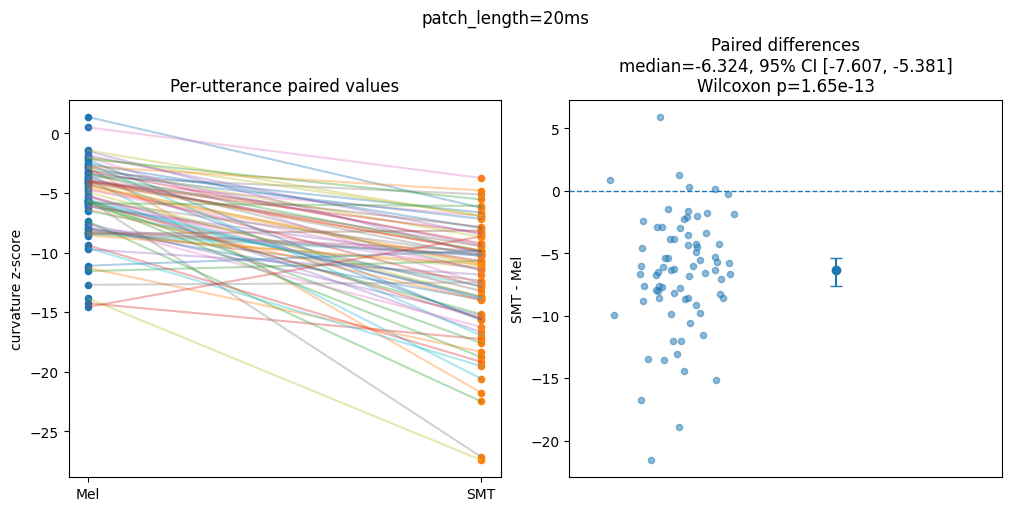

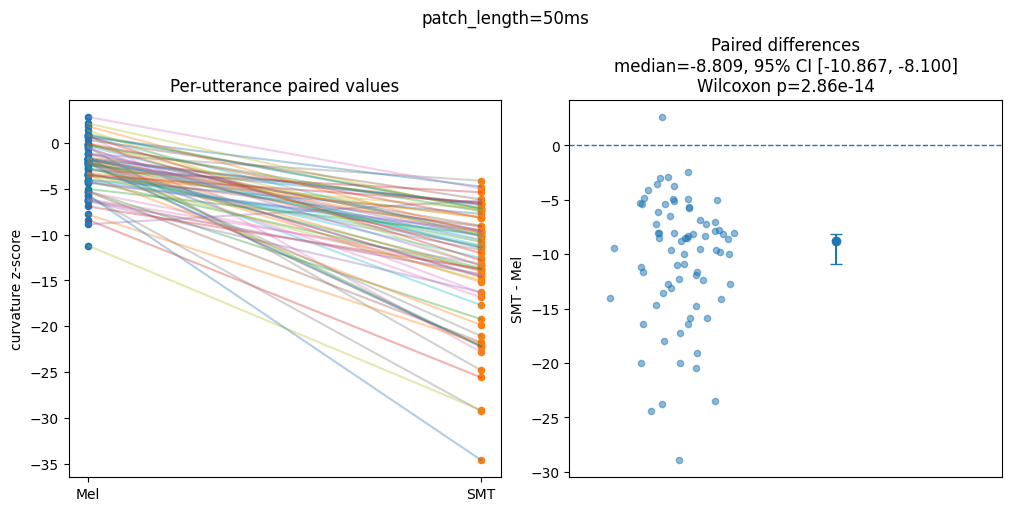

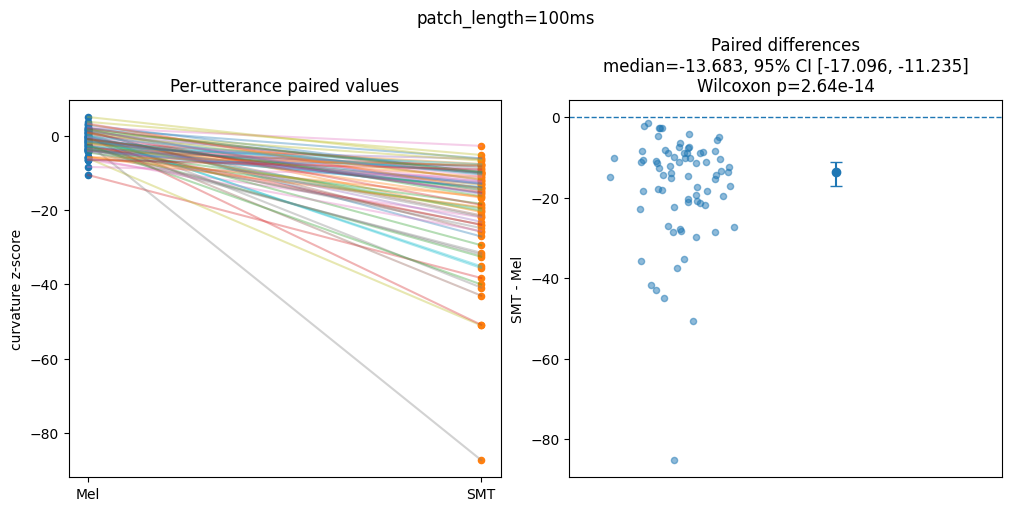

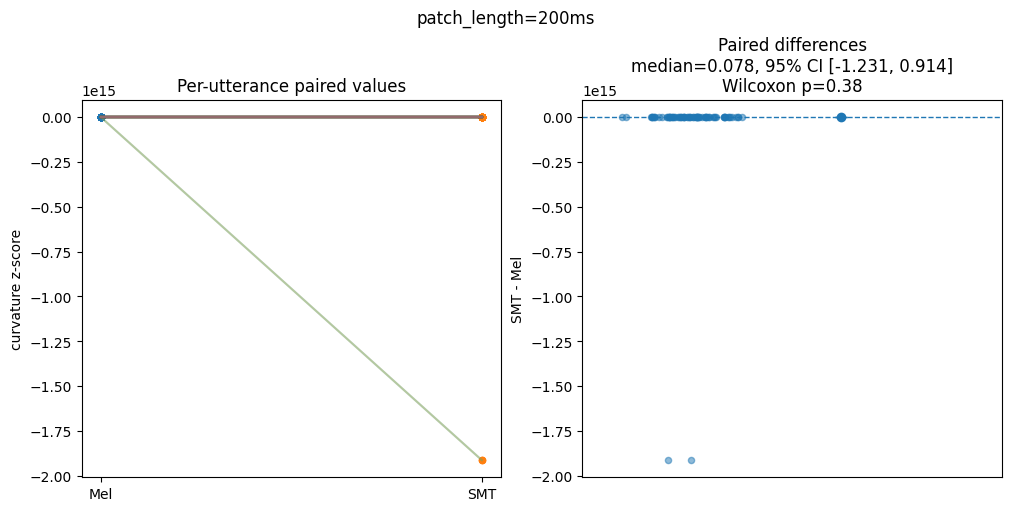

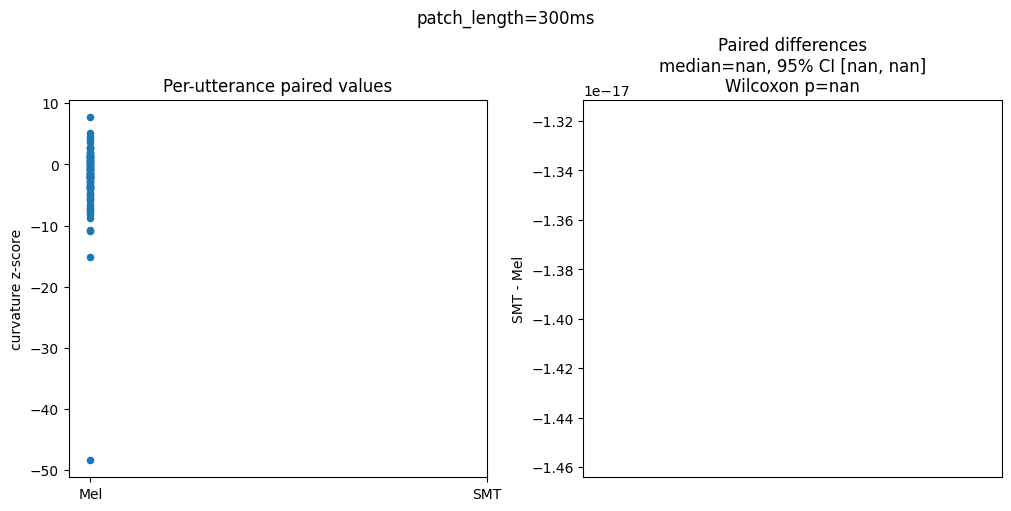

In [36]:
for i in patch_lengths:
    plot_paired_comparison(results[str(i)]['mel_stats']['z_score_linear'], results[str(i)]['smt_stats']['z_score_linear'], i, "curvature z-score", "less")

### Get mel/mfcc features from each file

In [98]:
audio_files = list_audio_files(AUDIO_DIRS[0])
n_mels = 20
out = extract_features_from_files(audio_files, n_mels=n_mels)

mels = [clip["mel_spectrogram"] for _, clip in out.items()]
mfccs = [clip["mfcc"] for _, clip in out.items()]
log_mels = [clip["log_mel_db"] for _, clip in out.items()]

hop_length = [clip["hop_length"] for _, clip in out.items()][0]
sr = [clip["sr"] for _, clip in out.items()][0]

print([a.shape for a in mels])

[(20, 627), (20, 373), (20, 697), (20, 1103), (20, 333), (20, 532), (20, 697), (20, 546), (20, 624), (20, 896), (20, 326), (20, 748), (20, 1111), (20, 823), (20, 669), (20, 539), (20, 898), (20, 289), (20, 284), (20, 1148), (20, 556), (20, 399), (20, 455), (20, 278), (20, 982), (20, 686), (20, 656), (20, 1637), (20, 2481), (20, 576), (20, 257), (20, 561), (20, 980), (20, 363), (20, 657), (20, 845), (20, 880), (20, 469), (20, 227), (20, 764), (20, 926), (20, 1537), (20, 688), (20, 935), (20, 298), (20, 656), (20, 154), (20, 840), (20, 344), (20, 549), (20, 314), (20, 441), (20, 1099), (20, 545), (20, 398), (20, 355), (20, 653), (20, 584), (20, 796), (20, 566), (20, 249), (20, 497), (20, 499), (20, 262), (20, 678), (20, 386), (20, 751), (20, 1230), (20, 543), (20, 683), (20, 718), (20, 234), (20, 247), (20, 367), (20, 279)]


In [7]:
len(mels)

75

### Plot example 

In [115]:
import matplotlib.pyplot as pl
%matplotlib qt6
idx = 0
fig, ax = plt.subplots(nrows=1, sharex=True)
img = librosa.display.specshow(log_mels[idx],x_axis='time', y_axis='mel', fmax=8000,ax=ax)
fig.colorbar(img, ax=[ax])
ax.set(title='Mel spectrogram')
ax.label_outer()
#img = librosa.display.specshow(mfccs[idx], x_axis='time', ax=ax[1])
#fig.colorbar(img, ax=[ax[1]])
# ax[1].set(title='MFCC')

In [14]:
print(sr)
print(hop_length)

16000
160


### Patch the mfcc/mel representations

In [95]:
patch_length = 80
patches, utterance_bounds = patch_multiple_utterances(log_mels, sr, hop_length, patch_length)

In [96]:
patches.shape

(47748, 20, 8)

### Plot patches

In [97]:
plot_first_n_mel_patches(patches.reshape(patches.shape[0], 20, 20), n_show=50, cols=5)

ValueError: cannot reshape array of size 7639680 into shape (47748,20,20)

### Preprocess and plot patches again

In [99]:
norm_patches, mean, zcaMatrix = preprocess_patches(patches)

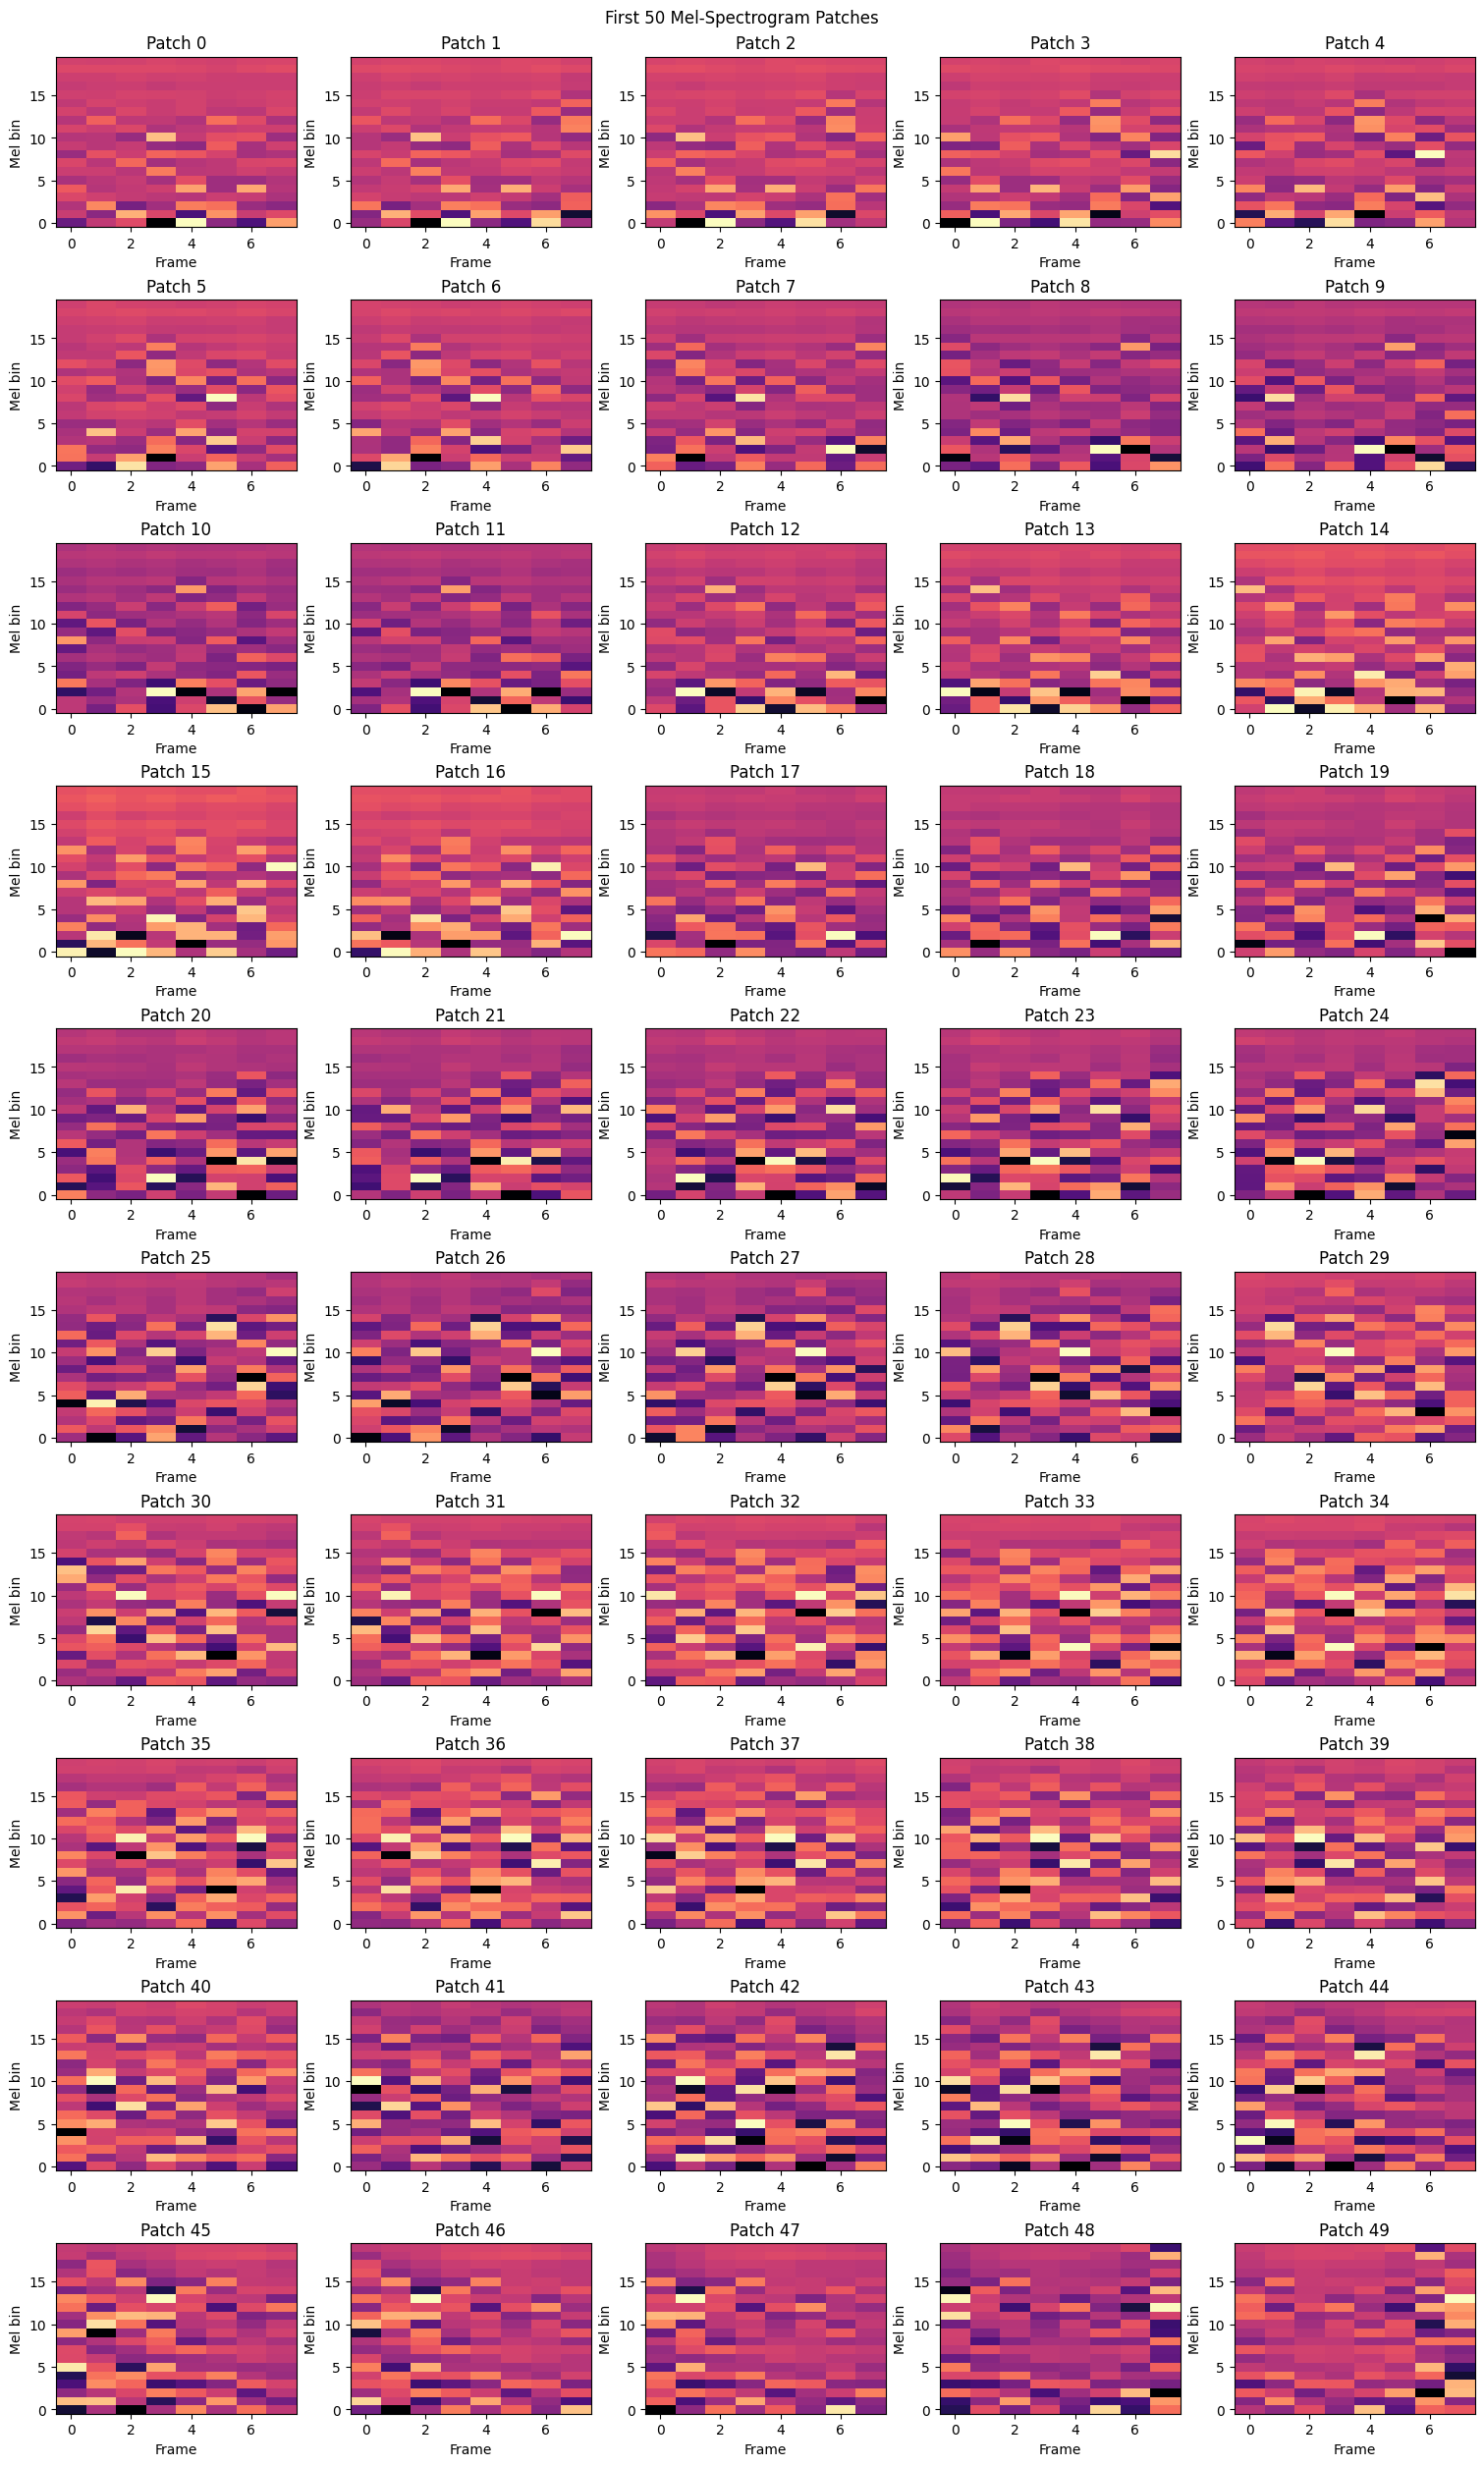

In [101]:
%matplotlib inline
plot_first_n_mel_patches(norm_patches.reshape(norm_patches.shape[0], n_mels, int(patch_length/10)), n_show=50, cols=5)

### sparse coding with kmeans on patches

In [102]:
kmeans=apply_kmeans_to_patches(norm_patches, 3200, sample_size=None)

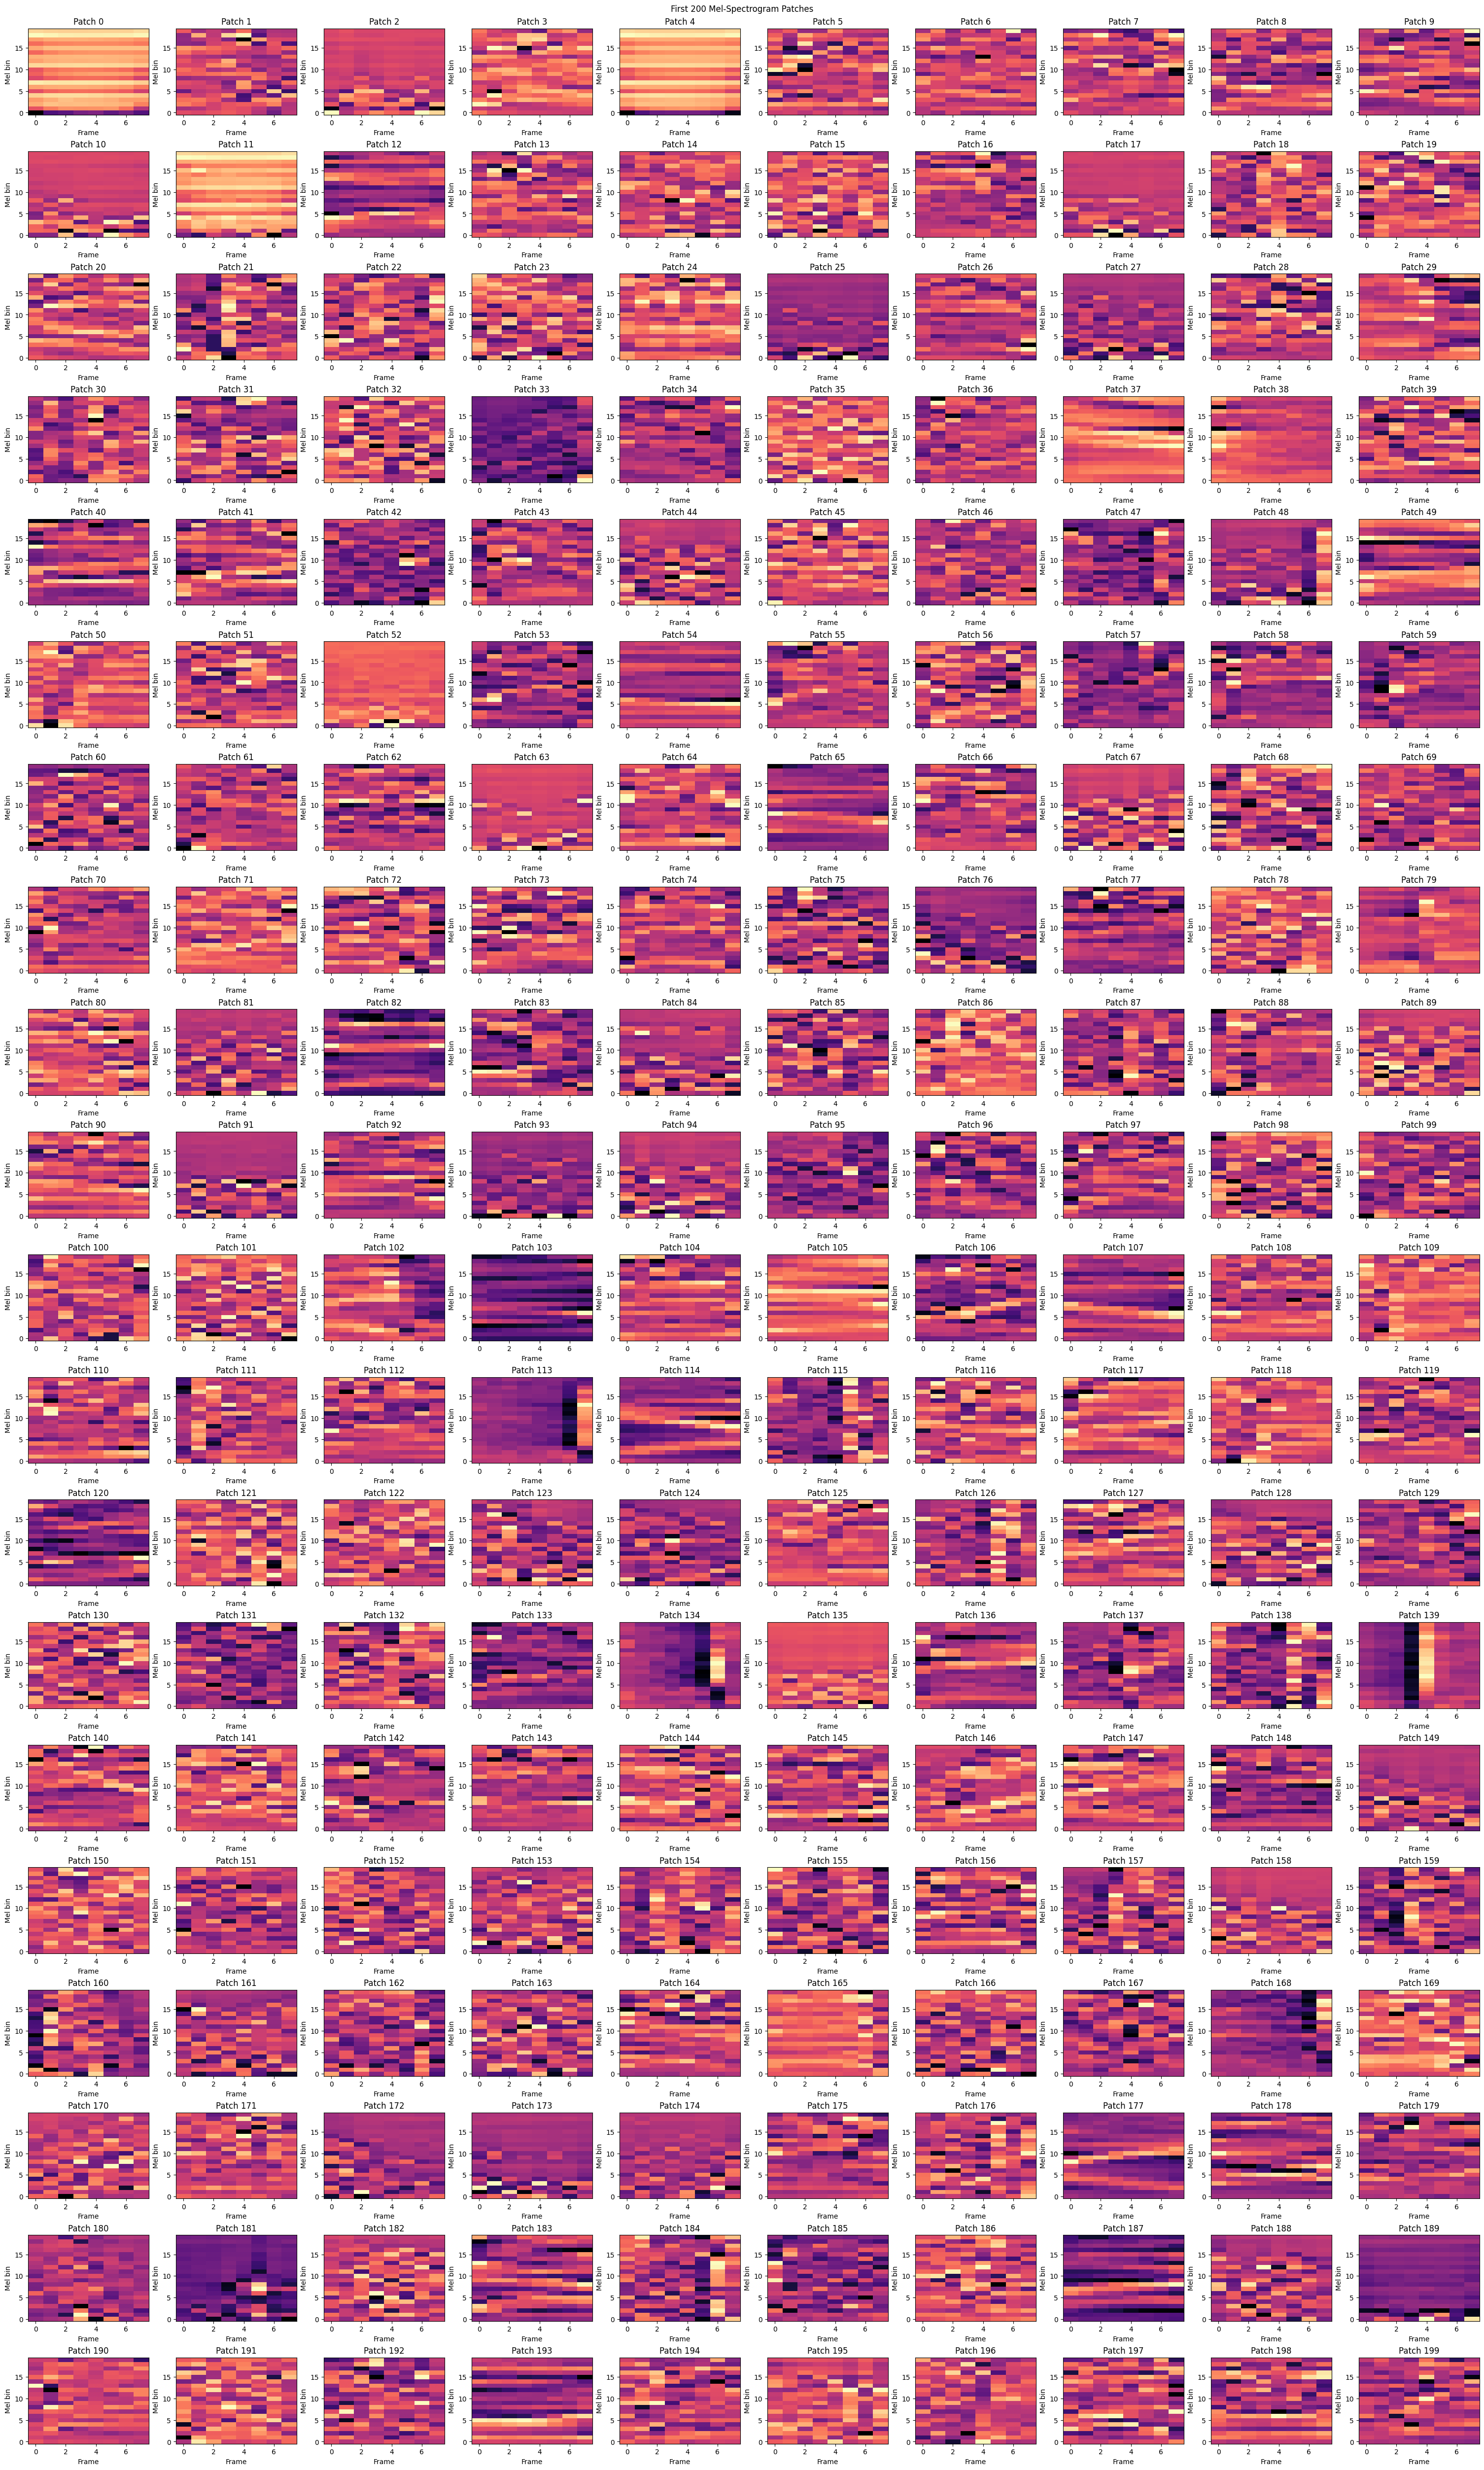

In [104]:
%matplotlib inline
clusters = kmeans.cluster_centers_
clusters = clusters.reshape(clusters.shape[0],n_mels,int(patch_length/10))
plot_first_n_mel_patches(clusters, 200, 10)

In [105]:
from FISTA import TopKSparseCoder
k_sparse_coder = TopKSparseCoder(torch.tensor(kmeans.cluster_centers_).to(dtype=torch.float32), 10, 100, True, True)

In [106]:
spars_codes = k_sparse_coder(torch.tensor(norm_patches).to(dtype=torch.float32))

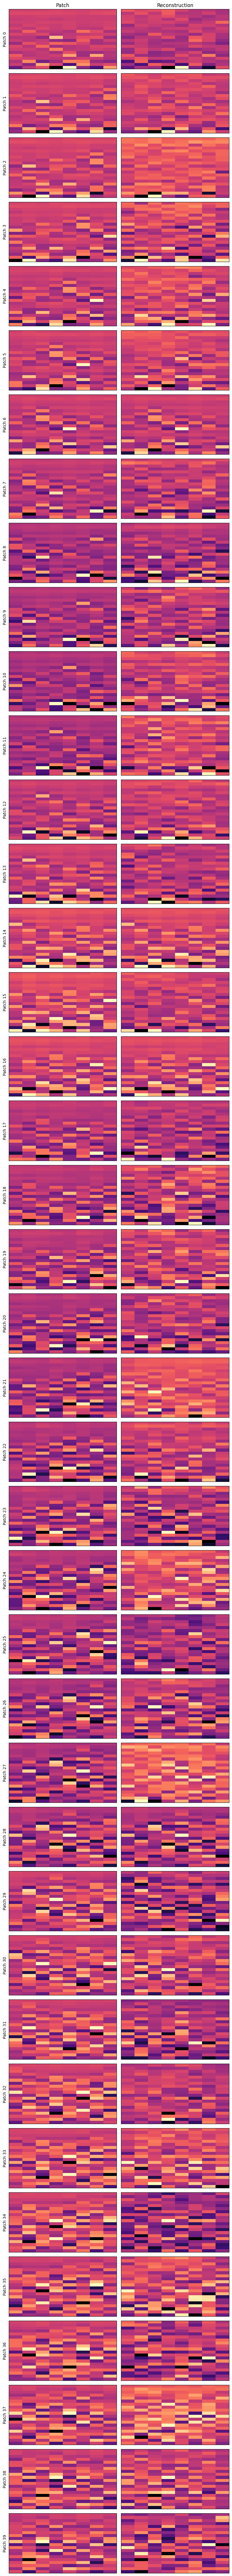

In [109]:
%matplotlib inline
n_show = 40  # first n patches
n_show = min(n_show, norm_patches.shape[0])

n_mels = 20
patch_frames = norm_patches.shape[1] // n_mels

fig, axes = plt.subplots(n_show, 2, figsize=(8, 2.2 * n_show), squeeze=False)
for idx in range(n_show):
    code = spars_codes[idx].detach().cpu().numpy() if torch.is_tensor(spars_codes[idx]) else np.asarray(spars_codes[idx])
    reconstruction = kmeans.cluster_centers_.T @ code

    axes[idx, 0].imshow(norm_patches[idx].reshape(n_mels, int(patch_length/10)), origin='lower', aspect='auto', cmap='magma')
    axes[idx, 0].set_ylabel(f"Patch {idx}")
    axes[idx, 0].set_xticks([])
    axes[idx, 0].set_yticks([])

    axes[idx, 1].imshow(reconstruction.reshape(n_mels, int(patch_length/10)), origin='lower', aspect='auto', cmap='magma')
    axes[idx, 1].set_xticks([])
    axes[idx, 1].set_yticks([])

axes[0, 0].set_title("Patch")
axes[0, 1].set_title("Reconstruction")
plt.tight_layout()

In [77]:
kmeans.cluster_centers_.shape

(3200, 320)

In [110]:
def spectral_decomp_dense_torch(
    A: torch.Tensor,
    utterance_bounds,
    eps: float = 1e-6,
):
    """
    A: (N, n_clusters) dense tensor
    """
    A = A.float()
    N, n_clusters = A.shape

    M = torch.zeros((n_clusters, n_clusters), device=A.device, dtype=A.dtype)

    for start, end in utterance_bounds:
        if end - start < 2:
            continue
        D = A[start + 1:end] - A[start:end - 1]   # (T-1, n_clusters)
        M += D.T @ D

    V = (A.T @ A) / N
    V += eps * torch.eye(n_clusters, device=A.device, dtype=A.dtype)

    L = torch.linalg.cholesky(V)
    Linv_M = torch.linalg.solve_triangular(L, M, upper=False, left=True)
    C = torch.linalg.solve_triangular(
        L, Linv_M.transpose(-1, -2), upper=False, left=True
    ).transpose(-1, -2)
    C = 0.5 * (C + C.T)

    eigvals, y = torch.linalg.eigh(C)
    eigvecs = torch.linalg.solve_triangular(L.T, y, upper=True, left=True)

    return eigvals, eigvecs

### Spectral decomposition on the support (i.e. the clusters) 

In [ ]:
#### P using 1-sparse codes

labels = kmeans.labels_
n_clusters = kmeans.n_clusters 
eigvals, eigvecs = spectral_decomp(labels, utterance_bounds, n_clusters)

# take smallest 32 eigenvectors as P
d = 128  # embedding dimension
P = eigvecs[:, 1:d+1].T

n_samples = labels.shape[0]

# Sparse cluster code: shape (n_samples, n_clusters)
A = csr_matrix(
    (np.ones(n_samples, dtype=np.float32), (np.arange(n_samples), labels)),
    shape=(n_samples, n_clusters),
)

A = A.T

# "sense" the manifold with P
beta = P@A

In [111]:
eigvals, eigvecs = spectral_decomp_dense_torch(spars_codes, utterance_bounds)
beta = P@spars_codes.T
beta.shape


torch.Size([128, 47748])

### check for smooth trajectories in embedding space

In [112]:
# z-score beta
norm_beta, _, _ = preprocess_patches(beta.T.numpy()) # this switches beta to be NxD like norm_patches
norm_beta = norm_beta

In [118]:
# PCA for one utterance from norm_beta, then plot first 2 PCs
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# pick utterance index
utt_idx = 0  # change as needed

start, end = utterance_bounds[utt_idx]
X_utt = norm_beta[start:end]  # shape: (T, D)

if X_utt.shape[0] < 2:
    raise ValueError(f"Utterance {utt_idx} has too few frames for PCA: {X_utt.shape[0]}")

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_utt)  # (T, 2)

plt.figure(figsize=(7, 5))
t = np.arange(X_pca.shape[0])
plt.plot(t, X_pca[:, 2])
# sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=t, cmap="viridis", s=18)
# plt.plot(X_pca[:, 0], X_pca[:, 1], alpha=0.35, linewidth=1)
# plt.colorbar(sc, label="time/frame index")
# plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
# plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
# plt.title(f"Utterance {utt_idx}: first two principal components")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [119]:
def calc_smoothness(data: np.ndarray):
    # assume data is NxD where N is the number of samples
    diff = np.diff(data, axis=0)
    diff_2 = np.diff(data, n=2, axis=0)

    grad_norm = np.linalg.norm(diff, ord=2, axis=1)
    grad_norm_2 = np.linalg.norm(diff_2, ord=2, axis=1)
    grad_median = np.median(grad_norm)
    grad_2_median = np.median(grad_norm_2)
    return grad_median, grad_2_median

def block_permute_rows(X, block_size, rng=None):
    """
    Permute rows of X by shuffling contiguous blocks.

    Parameters
    ----------
    X : np.ndarray
        Array of shape (n_rows, ...).
    block_size : int
        Number of rows per block.
    rng : np.random.Generator or None
        Optional RNG for reproducibility.

    Returns
    -------
    X_perm : np.ndarray
        Block-permuted array.
    """
    if rng is None:
        rng = np.random.default_rng()

    n_rows = X.shape[0]
    n_blocks = n_rows // block_size

    # Trim extra rows that don't fit into a full block
    trimmed = X[:n_blocks * block_size]

    blocks = trimmed.reshape(n_blocks, block_size, *X.shape[1:])
    perm = rng.permutation(n_blocks)

    permuted = blocks[perm].reshape(-1, *X.shape[1:])

    # Append leftover rows unchanged (optional)
    if n_rows % block_size != 0:
        permuted = np.concatenate([permuted, X[n_blocks * block_size:]], axis=0)

    return permuted

def compare_smoothness_to_null(data: np.ndarray, null_dist_size: int = 1000):
    # assume data is NxD where N is the number of samples
    obs_grad_median, obs_grad_2_median = calc_smoothness(data)

    perm_grad_medians = []
    perm_grad_2_medians = []
    for i in range(null_dist_size):
        perm_data = block_permute_rows(data, 10)#data[np.random.permutation(data.shape[0]),:]
        perm_grad_median, perm_grad_2_median = calc_smoothness(perm_data)
        perm_grad_medians.append(perm_grad_median)
        perm_grad_2_medians.append(perm_grad_2_median)

    perm_grad_medians = np.array(perm_grad_medians)
    perm_grad_2_medians = np.array(perm_grad_2_medians)

    z_score_smooth = (obs_grad_median - np.mean(perm_grad_medians)) / np.std(perm_grad_medians)
    z_score_linear = (obs_grad_2_median - np.mean(perm_grad_2_medians)) / np.std(perm_grad_2_medians)
    return obs_grad_2_median, obs_grad_2_median, z_score_smooth, z_score_linear

def calc_path_efficiency(data: np.ndarray):
    diff = np.diff(data, axis=0)
    grad_norm = np.linalg.norm(diff, ord=2, axis=1)
    denom = np.sum(grad_norm)
    nom = np.linalg.norm(data[-1,:] - data[0,:], ord=2)
    return nom/denom

In [120]:
# isolate single utterance
utterance = utterance_bounds[3]
sample_utterance_mel = norm_patches[utterance[0]:utterance[1],:]
sample_utterance_beta = norm_beta[utterance[0]:utterance[1],:]

# calc smoothness on sensed manifold and plot
obs_grad_median_beta, obs_grad_2_median_beta, z_score_smooth_beta, z_score_linear_beta = compare_smoothness_to_null(sample_utterance_beta)
obs_grad_median_mel, obs_grad_2_median_mel, z_score_smooth_mel, z_score_linear_mel = compare_smoothness_to_null(sample_utterance_mel)

In [121]:
beta_stats = {'obs_grad_median': [], 
             'obs_grad_2_median': [],
             'z_score_smooth': [],
             'z_score_linear': [],
             'path_efficiency': []}
mel_stats = {'obs_grad_median': [], 
             'obs_grad_2_median': [],
             'z_score_smooth': [],
             'z_score_linear': [],
             'path_efficiency': []}
for (start, end) in tqdm(utterance_bounds):
    sample_utterance_mel = norm_patches[start:end,:]
    sample_utterance_beta = norm_beta[start:end,:]

    # calc smoothness on sensed manifold and plot
    obs_grad_median_beta, obs_grad_2_median_beta, z_score_smooth_beta, z_score_linear_beta = compare_smoothness_to_null(sample_utterance_beta)
    path_efficiency = calc_path_efficiency(sample_utterance_beta)
    
    beta_stats['path_efficiency'].append(path_efficiency)
    beta_stats['obs_grad_median'].append(obs_grad_median_beta)
    beta_stats['obs_grad_2_median'].append(obs_grad_2_median_beta)
    beta_stats['z_score_smooth'].append(z_score_smooth_beta)
    beta_stats['z_score_linear'].append(z_score_linear_beta)
    
    obs_grad_median_mel, obs_grad_2_median_mel, z_score_smooth_mel, z_score_linear_mel = compare_smoothness_to_null(sample_utterance_mel)
    path_efficiency = calc_path_efficiency(sample_utterance_mel)

    mel_stats['path_efficiency'].append(path_efficiency)
    mel_stats['obs_grad_median'].append(obs_grad_median_mel)
    mel_stats['obs_grad_2_median'].append(obs_grad_2_median_mel)
    mel_stats['z_score_smooth'].append(z_score_smooth_mel)
    mel_stats['z_score_linear'].append(z_score_linear_mel)


  0%|          | 0/75 [00:00<?, ?it/s]

100%|██████████| 75/75 [00:42<00:00,  1.77it/s]


In [22]:
for i, eff in enumerate(beta_stats['path_efficiency']):
    print(i, eff - mel_stats['path_efficiency'][i])

0 -0.0014638693618561887
1 -0.0026139496945930605
2 -0.00126812213583107
3 -0.0009951391116347333
4 -0.000971862435718986
5 -0.0016061142367933276
6 -0.0014147123795588104
7 -0.0008511420170107663
8 -0.0017409129072023792
9 -0.0009454121175899736
10 -0.0017161937672590943
11 -0.001373426756548883
12 -0.0008923787629887806
13 -0.0008058764474275699
14 -0.0010855139885060175
15 0.0014113852898083308
16 -0.0006614262204579358
17 -0.0035099701493485473
18 0.0017155279635605132
19 0.0001934084195793545
20 -0.0004839736355178555
21 -0.0021124313343470263
22 -0.0012096101988046059
23 -0.0020241254405679848
24 -0.000729208437589034
25 -0.0008396007882811825
26 -0.00043325191685725825
27 -3.0549796833515344e-06
28 -0.0001230055834684937
29 -0.0012168067568589776
30 -0.0009138106396256195
31 -0.001972028057303625
32 0.002670766460423547
33 -0.0009534149174293773
34 0.003190311293386669
35 -0.0006229346726758544
36 -0.0007290029516886404
37 0.0008141978824815024
38 0.01968196948505006
39 -0.00083

In [122]:
from scipy.stats import wilcoxon
diffs = np.array(beta_stats['z_score_linear']) - np.array(mel_stats['z_score_linear'])
stat, p = wilcoxon(diffs, alternative='less')

print("Wilcoxon statistic:", stat)
print("p-value:", p)

Wilcoxon statistic: 2146.0
p-value: 0.9999297485972269


In [127]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

def paired_bootstrap_ci(diffs, n_boot=5000, alpha=0.05, rng=None):
    rng = np.random.default_rng(rng)
    diffs = np.asarray(diffs)
    boots = []
    n = len(diffs)
    for _ in range(n_boot):
        sample = rng.choice(diffs, size=n, replace=True)
        boots.append(np.median(sample))
    lo = np.percentile(boots, 100 * (alpha / 2))
    hi = np.percentile(boots, 100 * (1 - alpha / 2))
    return np.median(diffs), lo, hi

def plot_paired_comparison(metric_mel, metric_smt, metric_name="Curvature z-score"):
    metric_mel = np.asarray(metric_mel)
    metric_smt = np.asarray(metric_smt)
    diffs = metric_smt - metric_mel

    stat, p = wilcoxon(metric_smt, metric_mel, alternative="less")

    med_diff, ci_lo, ci_hi = paired_bootstrap_ci(diffs, rng=0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

    # Left: paired slope plot
    x0, x1 = 0, 1
    for a, b in zip(metric_mel, metric_smt):
        axes[0].plot([x0, x1], [a, b], alpha=0.35)
    axes[0].scatter(np.full_like(metric_mel, x0), metric_mel, s=20)
    axes[0].scatter(np.full_like(metric_smt, x1), metric_smt, s=20)
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(["Mel", "SMT"])
    axes[0].set_ylabel(metric_name)
    axes[0].set_title("Per-utterance paired values")

    # Right: paired differences
    jitter = np.random.default_rng(0).normal(0, 0.04, size=len(diffs))
    axes[1].scatter(jitter, diffs, alpha=0.5, s=20)
    axes[1].axhline(0, linestyle="--", linewidth=1)
    axes[1].errorbar(
        0.22, med_diff,
        yerr=[[med_diff - ci_lo], [ci_hi - med_diff]],
        fmt="o", capsize=4
    )
    axes[1].set_xlim(-0.15, 0.45)
    axes[1].set_xticks([])
    axes[1].set_ylabel("SMT - Mel")
    axes[1].set_title(
        f"Paired differences\nmedian={med_diff:.3f}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}]\n"
        f"Wilcoxon p={p:.3g}"
    )

    plt.show()
    return stat, p, med_diff, (ci_lo, ci_hi)

In [129]:
plot_paired_comparison(mel_stats['path_efficiency'], beta_stats['path_efficiency'])

(np.float64(1885.0),
 np.float64(0.9924309058181265),
 np.float64(6.255974747413858e-05),
 (np.float64(1.9607455970067656e-05), np.float64(0.00012148323488514468)))

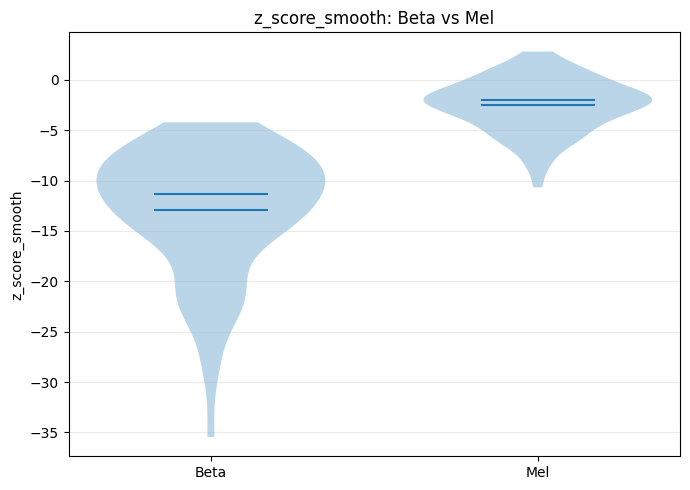

In [30]:
import numpy as np
import matplotlib.pyplot as plt

beta_z = np.asarray(beta_stats["z_score_linear"])
mel_z  = np.asarray(mel_stats["z_score_linear"])

fig, ax = plt.subplots(figsize=(7, 5))
parts = ax.violinplot(
    [beta_z, mel_z],
    positions=[1, 2],
    widths=0.7,
    showmeans=True,
    showmedians=True,
    showextrema=False,
)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Beta", "Mel"])
ax.set_ylabel("z_score_smooth")
ax.set_title("z_score_smooth: Beta vs Mel")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


In [ ]:
plt.plot(beta_stats["obs_grad_2_median"])
plt.plot(mel_stats["obs_grad_2_median"])

## Sparse coding using FISTA


In [ ]:
def quadraticBasisUpdate(basis, Res, ahat, lowestActivation, HessianDiag, stepSize = 0.001,constraint = 'L2', Noneg = False):
    """
    This matrix update the basis function based on the Hessian matrix of the activation.
    It's very similar to Newton method. But since the Hessian matrix of the activation function is often ill-conditioned, we takes the pseudo inverse.

    Note: currently, we can just use the inverse of the activation energy.
    A better idea for this method should be caculating the local Lipschitz constant for each of the basis.
    The stepSize should be smaller than 1.0 * min(activation) to be stable.
    """
    dBasis = stepSize*torch.mm(Res, ahat.t())/ahat.size(1)
    dBasis = dBasis.div_(HessianDiag+lowestActivation)
    basis = basis.add_(dBasis)
    if Noneg:
        basis = basis.clamp(min = 0.)
    if constraint == 'L2':
        basis = basis.div_(basis.norm(2,0))
    return basis
    
def FISTA(I,basis,lambd,num_iter,eta=None, useMAGMA=True):
    # This is a positive-only PyTorch-Ver FISTA solver
    dtype = basis.type()
    batch_size=I.size(1)
    M = basis.size(1)
    if eta is None:
        if useMAGMA:
            L = torch.max(torch.symeig(torch.mm(basis,basis.t()),eigenvectors=False)[0])
            eta = 1./L
        else:
            eta = 1./cp.linalg.eigvalsh(cp.asarray(torch.mm(basis,basis.t()).cpu().numpy())).max().get().reshape(1)
            eta = torch.from_numpy(eta.astype('float32')).cuda()

    tk_n = 1.
    tk = 1.
    Res = torch.cuda.FloatTensor(I.size()).fill_(0)
    ahat = torch.cuda.FloatTensor(M,batch_size).fill_(0)
    ahat_y = torch.cuda.FloatTensor(M,batch_size).fill_(0)

    for t in range(num_iter):
        tk = tk_n
        tk_n = (1+np.sqrt(1+4*tk**2))/2
        ahat_pre = ahat
        Res = I - torch.mm(basis,ahat_y)
        ahat_y = ahat_y.add(eta * basis.t().mm(Res))
        ahat = ahat_y.sub(eta * lambd).clamp(min = 0.)
        ahat_y = ahat.add(ahat.sub(ahat_pre).mul((tk-1)/(tk_n)))
    Res = I - torch.mm(basis,ahat)
    return ahat, Res